In [4]:
import duckdb
import pandas as pd

# Troubleshooting empty UMIs

In [86]:
# df = pd.read_csv("../../output/GCN4_pipeline/trebl_experiment_pool_C_umi_/trebl_experiment_pool_C_umi_AD_1_15/AD_1__umi_count_input.tsv", sep = "\t", nrows = 1000, header = None)
# df[0].str.len().value_counts()

In [12]:
df[df[0].str.len() == 1]

,0,1
209,_,AAAAATATCTTTAATGATGATTTGGTTCTGCTCCACCATCTCTGCT...
220,_,AAAAATCAACATGTTGTTGCTGATGTTTCTAGAGATAGAATTACTA...
249,_,AAAAATGATCCAGATGATCCAGTTGCTGTTAAGAGAGCTAGAAATA...
251,_,AAAAATGATCCAGATGATCCAGTTGCTGTTAAGAGAGCTAGAAATA...
258,_,AAAAATGATCCAGATGATCCAGTTGCTGTTAAGAGAGCTAGAAATA...
259,_,AAAAATGATCCAGATGATCCAGTTGCTGTTAAGAGAGCTAGAAATA...
260,_,AAAAATGATCCAGATGATCCAGTTGCTGTTAAGAGAGCTAGAAATA...
267,_,AAAAATGATCCAGATGATCCAGTTGCTGTTAAGAGAGCTAGAAATA...
269,_,AAAAATGATCCAGATGATCCAGTTGCTGTTAAGAGAGCTAGAAATA...
270,_,AAAAATGATCCAGATGATCCAGTTGCTGTTAAGAGAGCTAGAAATA...


In [3]:
con = duckdb.connect("../../duckdb/GCN4_pipeline.db")
con

In [14]:
tables = con.execute("SHOW TABLES").fetchdf()
tables

,name
0,design
1,step2_AD_AD_BC_barcode_exists
2,step2_AD_AD_BC_designed
3,step2_AD_AD_BC_initial
4,step2_AD_AD_BC_initial_grouped
...,...
459,trebl_experiment_pool_C_umi_AD_2_240_AD_AD_BC_...
460,trebl_experiment_pool_C_umi_AD_2_240_AD_AD_BC_...
461,trebl_experiment_pool_C_umi_AD_2_240_AD_AD_BC_...
462,trebl_experiment_pool_C_umi_AD_2_240_AD_AD_BC_...


In [18]:
for name in tables[tables["name"].str.contains("AD_1_15")]["name"]:
    print(name)

trebl_experiment_pool_C_umi_AD_1_15_AD_AD_BC_initial
trebl_experiment_pool_C_umi_AD_1_15_AD_AD_BC_loss_summary
trebl_experiment_pool_C_umi_AD_1_15_AD_AD_BC_quality
trebl_experiment_pool_C_umi_AD_1_15_AD_AD_BC_quality_umis_collapsed
trebl_experiment_pool_C_umi_AD_1_15_AD_AD_BC_unique_barcodes


In [20]:
quality_head = con.execute("SELECT * FROM trebl_experiment_pool_C_umi_AD_1_15_AD_AD_BC_quality LIMIT 1000 ").fetchdf()
quality_head

,AD,AD_qual,AD_BC,AD_BC_qual,UMI,UMI_qual,Designed
0,TCTCCAGTTATCTTGAATGATACATTTATTGGTTCTAATCCAGTTG...,True,ACTGAACACAA,True,ACCATATACTAA,True,1
1,TTTATGTCTGCTCCAAATTCTACTGCTTTGACTGCTTTGACTTCTC...,True,CAAAGTTCGGC,True,GAACCAAAACGA,True,1
2,TCTGCTAATGGTGGTGTTAATCAGAATCAACAACATAGATCTCAAC...,True,TGTTGGCGCGA,True,ATCTCACAAAGG,True,1
3,GTTGATGATGATTCTATTGTTCCACATGATGAAGTCTTGGAAGCTT...,True,AGATCGATAGC,True,CCTAAACGGTAG,True,1
4,TTCTTCTCTTCTTCTGTTGATTCTACTCCAATGTTTGATTTGGATG...,True,CCCCACCGGCC,True,CGATCGAGTCAC,True,1
...,...,...,...,...,...,...,...
995,GAAGAATCTTTGCCATGTCCATCTTCTGTTCCAGCTCCACCATTTG...,True,ACTCAAAGTTA,True,ACTCCCACCTAG,True,1
996,CCATCTCCAGAAGCATTTGCTGCTTCTACTTCTATTAGAATTGCTT...,True,AAAGCGGAAAA,True,ACGCACCGCCTA,True,1
997,ACTACTAGAAGAAGATCTGGTACTGGTGGTTCTTCTCCAACTTCTG...,True,ATCTTGAATCT,True,AACACTAACCGG,True,1
998,ACTTCTCCATTGTTTGGTGCTGAAGATACTAATGGTGATAATTGGT...,True,ACGTATCTAGT,True,ACTTGGACCGCC,True,1


In [23]:
quality_head[quality_head["UMI"].str.len() == 0]

,AD,AD_qual,AD_BC,AD_BC_qual,UMI,UMI_qual,Designed
83,TCTTTGCAACAAGACTTTGTCTTGTTTGATCAACCAACTCATCCAA...,True,TAATGGAAACG,True,,False,1
136,TCTACTGAATTGGGTACTCCACAATCTGCATTTGATTCTCCAGCTG...,True,TGTTCTCATAT,True,,False,1
137,TCTACTGAATTGGGTACTCCACAATCTGCATTTGATTCTCCAGCTG...,True,TGTTCTCATAT,True,,False,1
556,GGTACTGAACATCCACAAGCTCATTTGTCTCCAGCTTCTTCTAGAA...,True,GGGGCCGGCAG,True,,False,1
738,TTGGTCTTTGGTAAATTTAATCAAGATCAACAAGCTATCTTGAGAG...,True,TGAACCCCGGA,True,,False,1
814,GAATTGGTTGATCCACCTAAACCATCTCAATCTCCATTGGTCTTGG...,True,TTAGTTTTTAA,True,,False,1
843,TCTGCTAAGAATGCTGATGAAATCTTGAAGAAAGCTAGAGTCTTGG...,True,ATGCAGCAAGA,True,,False,1
857,TCATTCTATGTCTTTGGTTCTCCAGTTTCTCAATCTAGATCTCCAG...,True,CTACAGTGCGA,True,,False,1


In [21]:
quality_head["UMI"].str.len().value_counts()

UMI
12    992
0       8
Name: count, dtype: int64

In [24]:
con.close()

# Plotting difference

In [87]:
directional = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/trebl_experiment_pool_C_umi_/trebl_experiment_pool_C_umi_AD_1_240/AD_1_240_directional_umi_counts.tsv", sep = "\t")
directional

,gene,count
0,AAAAAAAAACCAACCCTTGACGCTTCTTCTTTTTGTTTGTATGAAT...,1
1,AAAAAAAAACCCCCTCCTCTTCCCTCTCCAGCTTCCAATTCTAATG...,1
2,AAAAAAAAAGAGAAAACACTGCCACCAACTCCTTTTGATGATCCAT...,1
3,AAAAAAAACCTGATTTCTTTTTTTTGTTTTTCAAAAACTGGTGCTA...,1
4,AAAAAAAATGAAACTTCTTTGGCTGAGAAAAATGTTGAATTGGAAT...,1
...,...,...
2886376,TTTTTTTTTTCTTCTCCTCCCCCAACTGCACAAAAATCTACTCCAA...,1
2886377,TTTTTTTTTTCTTCTGTTGATTCTCCTCCCACGTTTGATTTGGATG...,1
2886378,TTTTTTTTTTCTTCTTATCCCACTATTTATCATTTTCAATCATTTA...,1
2886379,TTTTTTTTTTCTTCTTTTTCTCTTTCAACTCCCAATAAGCATGGTA...,1


In [88]:
simple = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/trebl_experiment_pool_C_umi_/trebl_experiment_pool_C_umi_AD_1_240/AD_1_240_simple_umi_counts.tsv", sep = "\t")
simple["gene"] = simple["AD"] + simple["AD_BC"]
simple

,AD,AD_BC,count,gene
0,CCATCTGACTTTCCATTTCCAGAAACTTTGACTTCTTCTACTGCTT...,TTATTCGAATT,23686,CCATCTGACTTTCCATTTCCAGAAACTTTGACTTCTTCTACTGCTT...
1,TCTTCTTCATTTGGTTTGTCTGGTAATTCTTCTCAACATAGATTGT...,CGCGGCTACAA,13872,TCTTCTTCATTTGGTTTGTCTGGTAATTCTTCTCAACATAGATTGT...
2,TTTCCACCATCTTCTCCATCTATGACTACTGAAATGGTTTCTTTGC...,AGTAACAGCTG,13279,TTTCCACCATCTTCTCCATCTATGACTACTGAAATGGTTTCTTTGC...
3,AATACATTTCATTCTGCTTATTCTTCTCCAGCTGTTCCAACTTTGT...,ATACCGCCAAC,11091,AATACATTTCATTCTGCTTATTCTTCTCCAGCTGTTCCAACTTTGT...
4,AGACCAGCTAGACCACCAGTTCCATTGTTCTCTCAATCTACTGGTT...,TCCTAAGCTCG,10784,AGACCAGCTAGACCACCAGTTCCATTGTTCTCTCAATCTACTGGTT...
...,...,...,...,...
2886376,TCATTTGAAACTTCTCCAATGTTTCAAGGTGAATCAATGTTAAATT...,ACTACTTTAGT,1,TCATTTGAAACTTCTCCAATGTTTCAAGGTGAATCAATGTTAAATT...
2886377,TCTATTACATTCTATCCACCAGACTTTCCATCTCAAGAGAATTTGT...,AACACAAGTAG,1,TCTATTACATTCTATCCACCAGACTTTCCATCTCAAGAGAATTTGT...
2886378,ACTTATTCTTCTCCAGCTATGCCAAATTTGTTTGATATGTCTGGTG...,CTAAATGCGGA,1,ACTTATTCTTCTCCAGCTATGCCAAATTTGTTTGATATGTCTGGTG...
2886379,TTGACTCATGATCAAGTTTCTTCTTCTTTGTTGAATACTGAGAACT...,CTACGGAGCAA,1,TTGACTCATGATCAAGTTTCTTCTTCTTTGTTGAATACTGAGAACT...


In [89]:
count_comparison = pd.merge(simple, directional, on = 'gene', suffixes = ("_simple", "_directional"))
count_comparison

,AD,AD_BC,count_simple,gene,count_directional
0,CCATCTGACTTTCCATTTCCAGAAACTTTGACTTCTTCTACTGCTT...,TTATTCGAATT,23686,CCATCTGACTTTCCATTTCCAGAAACTTTGACTTCTTCTACTGCTT...,22095
1,TCTTCTTCATTTGGTTTGTCTGGTAATTCTTCTCAACATAGATTGT...,CGCGGCTACAA,13872,TCTTCTTCATTTGGTTTGTCTGGTAATTCTTCTCAACATAGATTGT...,13120
2,TTTCCACCATCTTCTCCATCTATGACTACTGAAATGGTTTCTTTGC...,AGTAACAGCTG,13279,TTTCCACCATCTTCTCCATCTATGACTACTGAAATGGTTTCTTTGC...,12523
3,AATACATTTCATTCTGCTTATTCTTCTCCAGCTGTTCCAACTTTGT...,ATACCGCCAAC,11091,AATACATTTCATTCTGCTTATTCTTCTCCAGCTGTTCCAACTTTGT...,10496
4,AGACCAGCTAGACCACCAGTTCCATTGTTCTCTCAATCTACTGGTT...,TCCTAAGCTCG,10784,AGACCAGCTAGACCACCAGTTCCATTGTTCTCTCAATCTACTGGTT...,10208
...,...,...,...,...,...
2886376,TCATTTGAAACTTCTCCAATGTTTCAAGGTGAATCAATGTTAAATT...,ACTACTTTAGT,1,TCATTTGAAACTTCTCCAATGTTTCAAGGTGAATCAATGTTAAATT...,1
2886377,TCTATTACATTCTATCCACCAGACTTTCCATCTCAAGAGAATTTGT...,AACACAAGTAG,1,TCTATTACATTCTATCCACCAGACTTTCCATCTCAAGAGAATTTGT...,1
2886378,ACTTATTCTTCTCCAGCTATGCCAAATTTGTTTGATATGTCTGGTG...,CTAAATGCGGA,1,ACTTATTCTTCTCCAGCTATGCCAAATTTGTTTGATATGTCTGGTG...,1
2886379,TTGACTCATGATCAAGTTTCTTCTTCTTTGTTGAATACTGAGAACT...,CTACGGAGCAA,1,TTGACTCATGATCAAGTTTCTTCTTCTTTGTTGAATACTGAGAACT...,1


In [90]:
count_comparison["count_diff"] = count_comparison["count_simple"] - count_comparison["count_directional"]
count_comparison

,AD,AD_BC,count_simple,gene,count_directional,count_diff
0,CCATCTGACTTTCCATTTCCAGAAACTTTGACTTCTTCTACTGCTT...,TTATTCGAATT,23686,CCATCTGACTTTCCATTTCCAGAAACTTTGACTTCTTCTACTGCTT...,22095,1591
1,TCTTCTTCATTTGGTTTGTCTGGTAATTCTTCTCAACATAGATTGT...,CGCGGCTACAA,13872,TCTTCTTCATTTGGTTTGTCTGGTAATTCTTCTCAACATAGATTGT...,13120,752
2,TTTCCACCATCTTCTCCATCTATGACTACTGAAATGGTTTCTTTGC...,AGTAACAGCTG,13279,TTTCCACCATCTTCTCCATCTATGACTACTGAAATGGTTTCTTTGC...,12523,756
3,AATACATTTCATTCTGCTTATTCTTCTCCAGCTGTTCCAACTTTGT...,ATACCGCCAAC,11091,AATACATTTCATTCTGCTTATTCTTCTCCAGCTGTTCCAACTTTGT...,10496,595
4,AGACCAGCTAGACCACCAGTTCCATTGTTCTCTCAATCTACTGGTT...,TCCTAAGCTCG,10784,AGACCAGCTAGACCACCAGTTCCATTGTTCTCTCAATCTACTGGTT...,10208,576
...,...,...,...,...,...,...
2886376,TCATTTGAAACTTCTCCAATGTTTCAAGGTGAATCAATGTTAAATT...,ACTACTTTAGT,1,TCATTTGAAACTTCTCCAATGTTTCAAGGTGAATCAATGTTAAATT...,1,0
2886377,TCTATTACATTCTATCCACCAGACTTTCCATCTCAAGAGAATTTGT...,AACACAAGTAG,1,TCTATTACATTCTATCCACCAGACTTTCCATCTCAAGAGAATTTGT...,1,0
2886378,ACTTATTCTTCTCCAGCTATGCCAAATTTGTTTGATATGTCTGGTG...,CTAAATGCGGA,1,ACTTATTCTTCTCCAGCTATGCCAAATTTGTTTGATATGTCTGGTG...,1,0
2886379,TTGACTCATGATCAAGTTTCTTCTTCTTTGTTGAATACTGAGAACT...,CTACGGAGCAA,1,TTGACTCATGATCAAGTTTCTTCTTCTTTGTTGAATACTGAGAACT...,1,0


In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

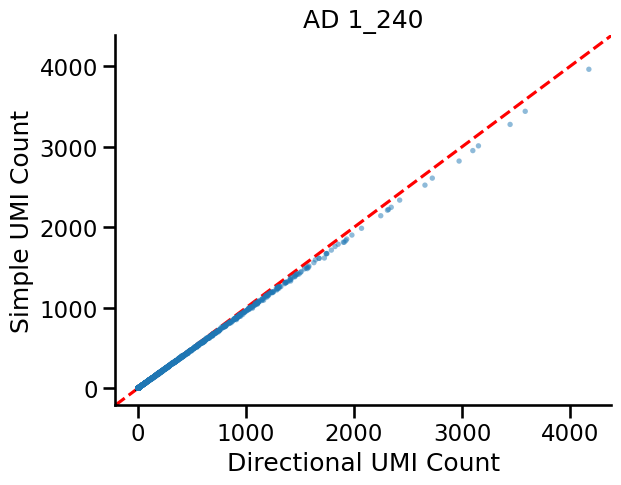

In [114]:
sns.set_context('talk')

ax = sns.scatterplot(
    data=count_comparison.sample(100000, random_state = 7),
    x="count_simple",
    y="count_directional",
    edgecolor='none',
    alpha=0.5,
    s = 15
)

# add y = x line
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1])
]

ax.plot(lims, lims, '--', color='red',zorder = 0)
ax.set_xlim(lims)
ax.set_ylim(lims)

plt.ylabel("Simple UMI Count")
plt.xlabel("Directional UMI Count")
sns.despine()
plt.title("AD 1_240")
plt.show()


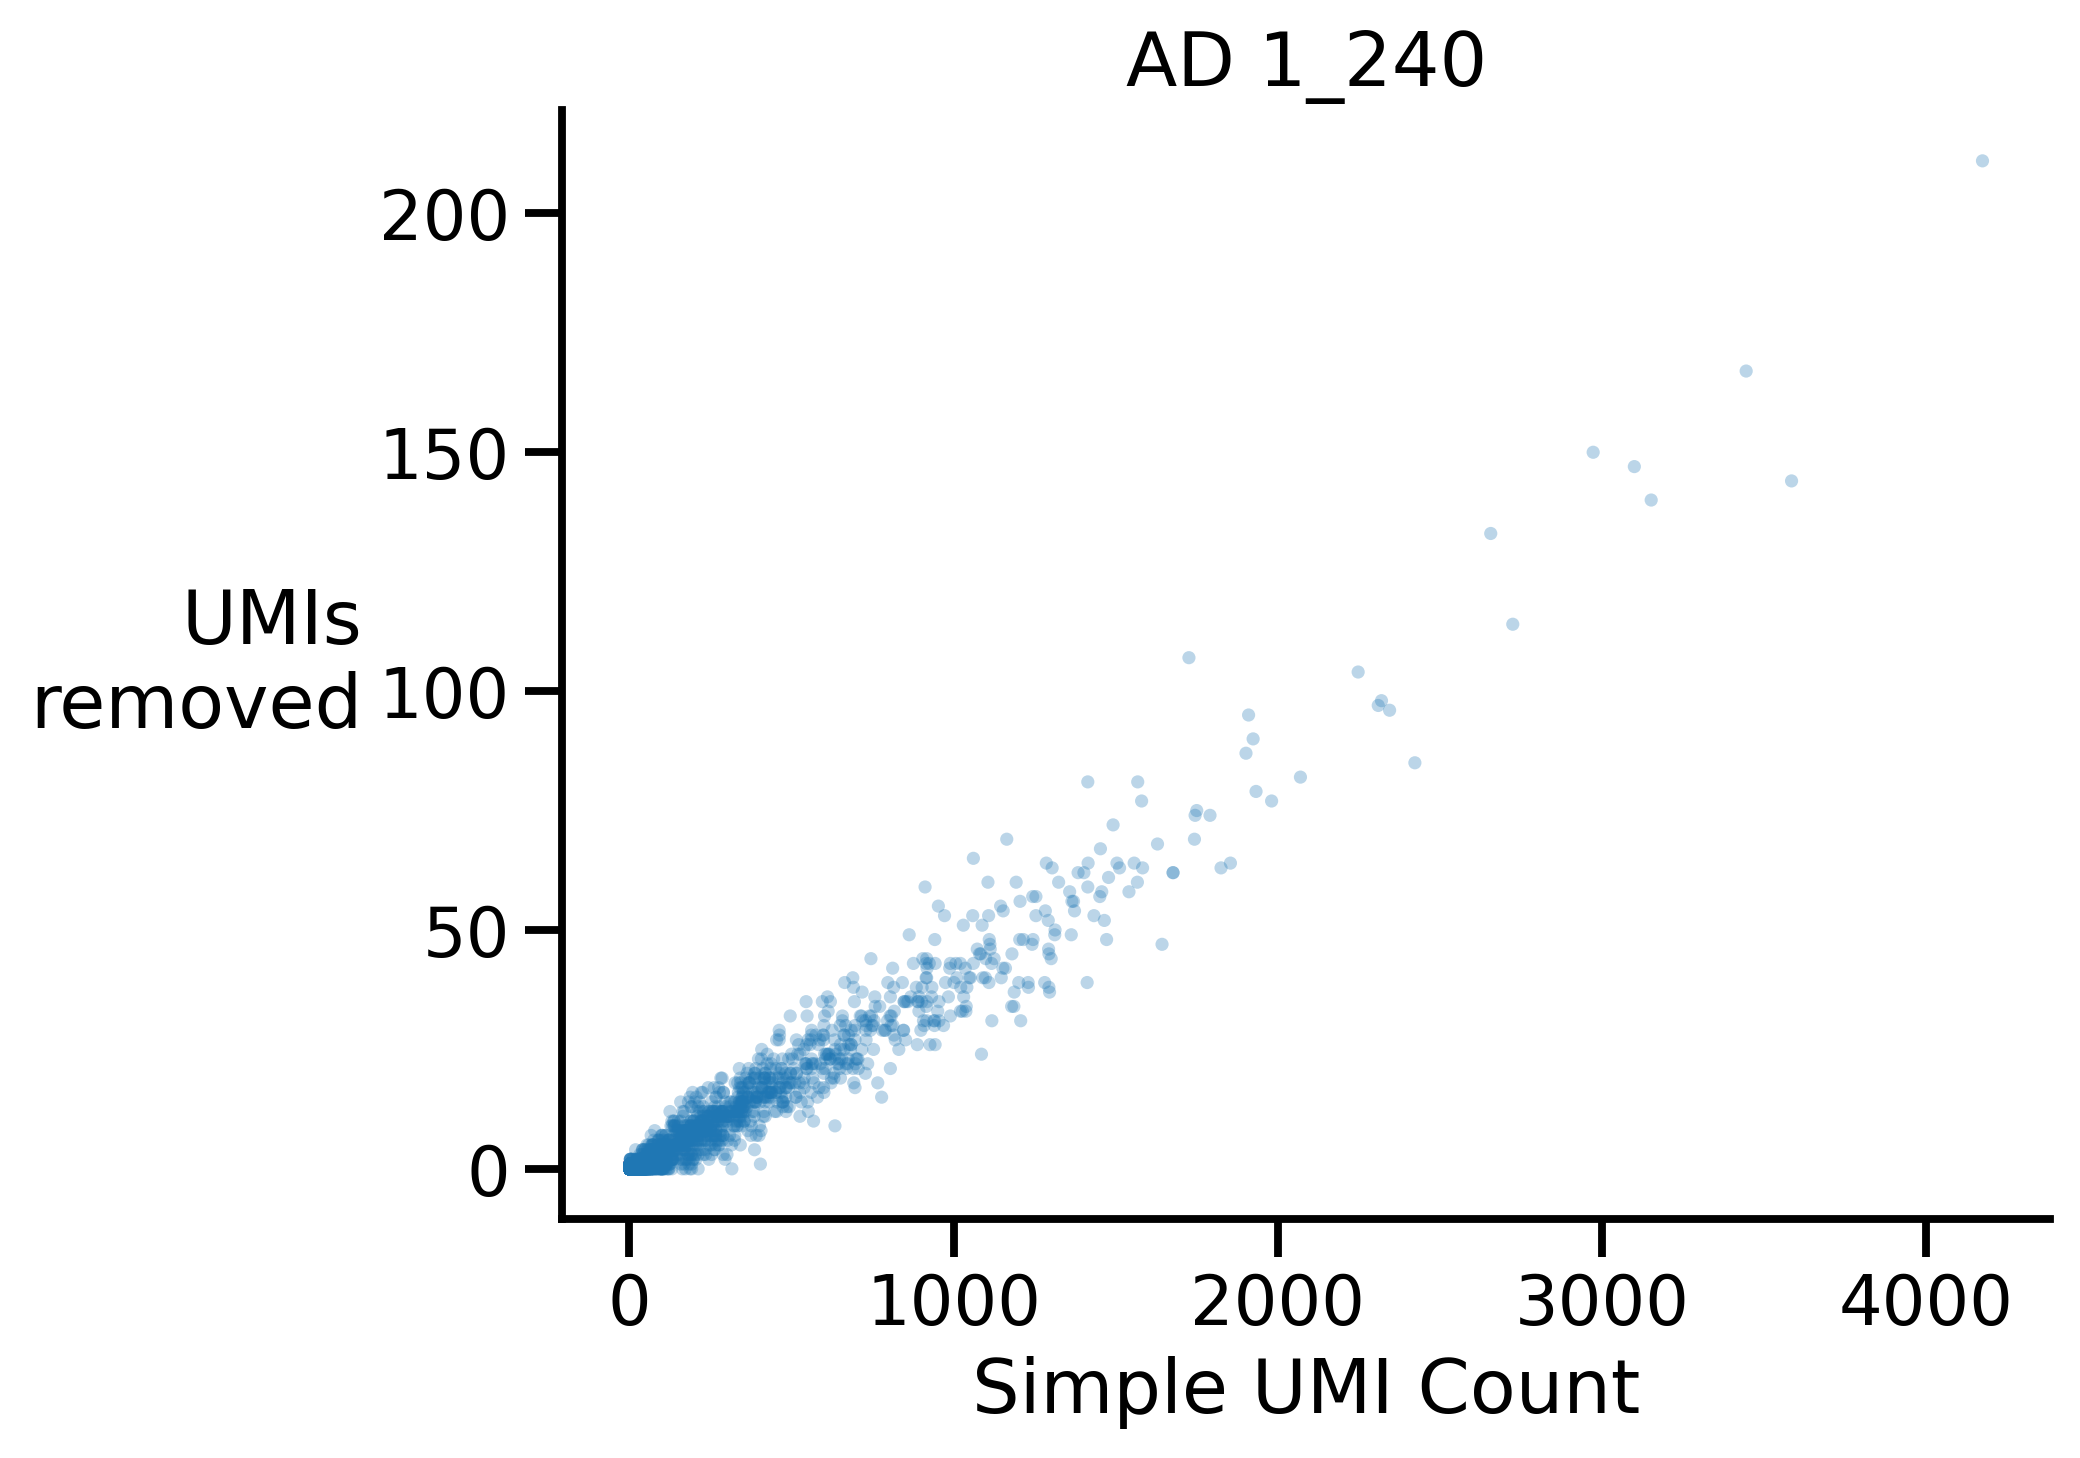

In [113]:
plt.figure(dpi = 300)

ax = sns.scatterplot(
    data=count_comparison.sample(100000, random_state=7),
    x="count_simple",
    y="count_diff",
    edgecolor="none",
    alpha=0.3,
    s=10
)

# Get max range across both axes
max_val = max(
    count_comparison["count_simple"].max(),
    count_comparison["count_diff"].max()
)


ax.set_ylabel("UMIs\nremoved", rotation = 0, va = 'center', ha = 'right')
ax.set_xlabel("Simple UMI Count")

# Make axes visually equal
# ax.set_aspect('equal', adjustable='box')
plt.title("AD 1_240")

sns.despine()